✅ Step 0 done — libraries loaded

📁 Upload: Combined_Meteorological_Dataset_Full_Year.xlsx


Saving Combined_Meteorological_Dataset_Full_Year.xlsx to Combined_Meteorological_Dataset_Full_Year (1).xlsx
Raw shape : (60074, 10)
Date range: 2024-08-16 11:10:00 → 2025-10-07 15:20:00
Missing   :
TIMESTAMP        0
GHI          15442
DNI          15442
DHI          15442
Tair         15442
RH           15442
BP           15442
WS           15442
WD           15442
WSgust       15442
dtype: int64

✅ Step 2 done — clean shape: (44632, 16)


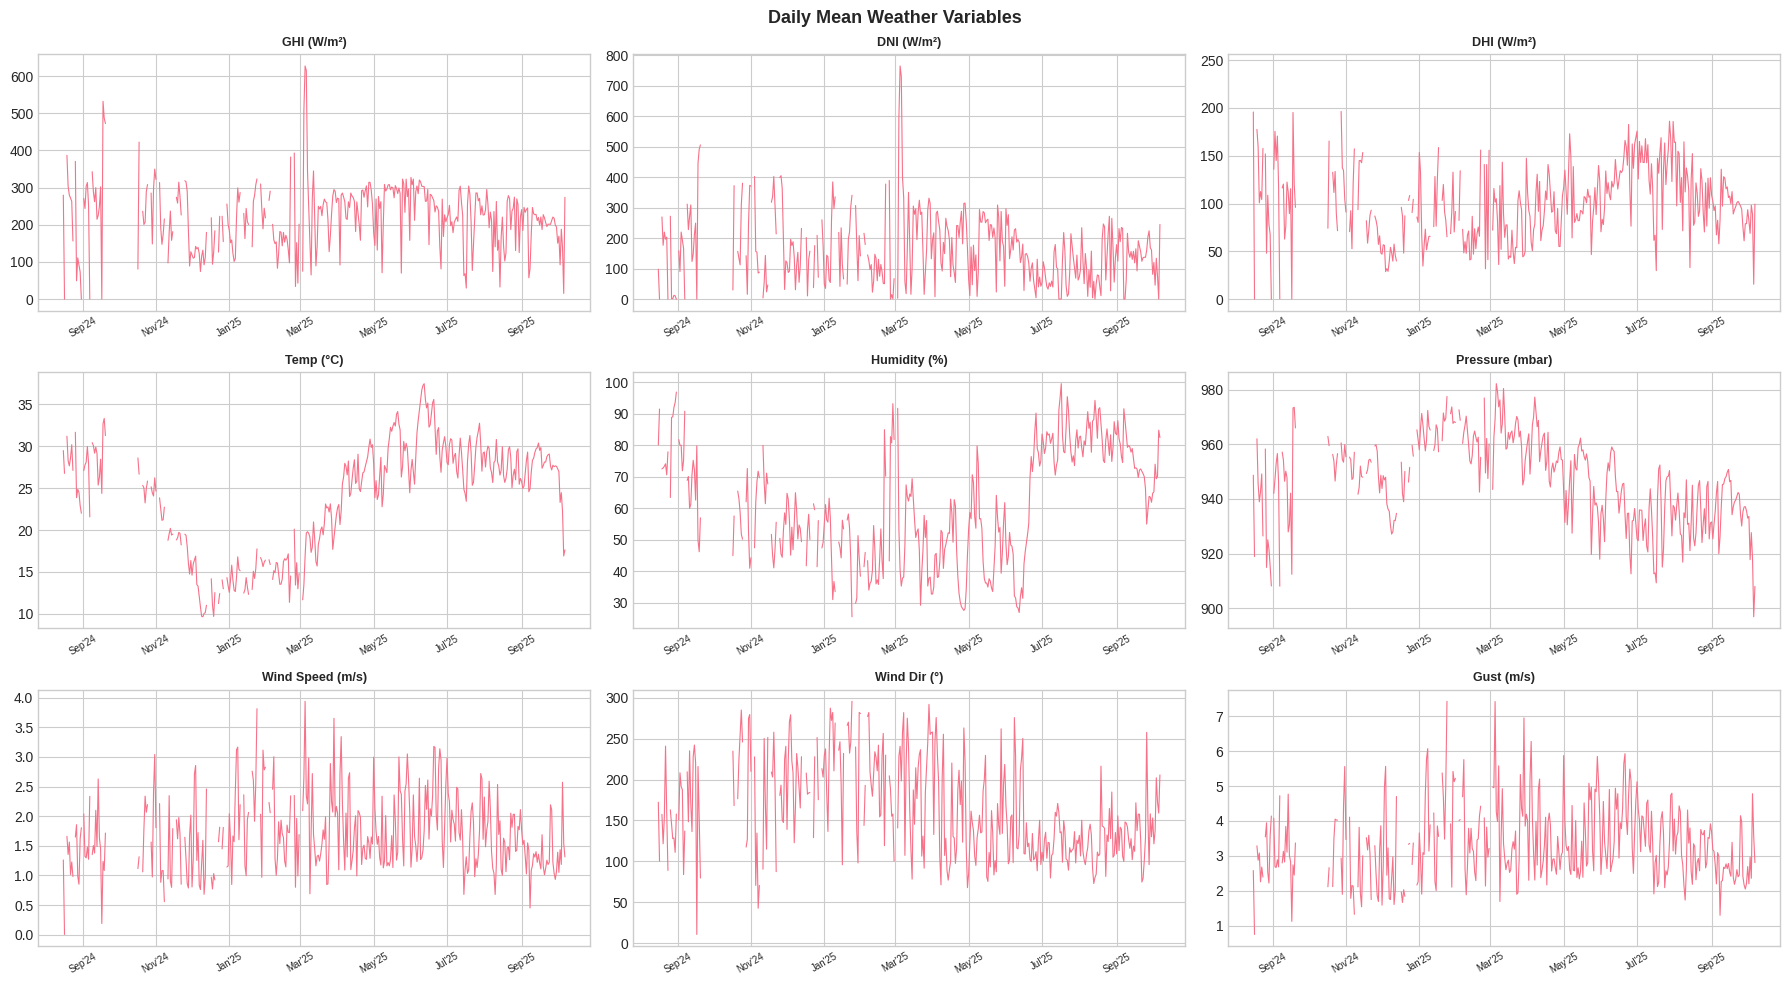

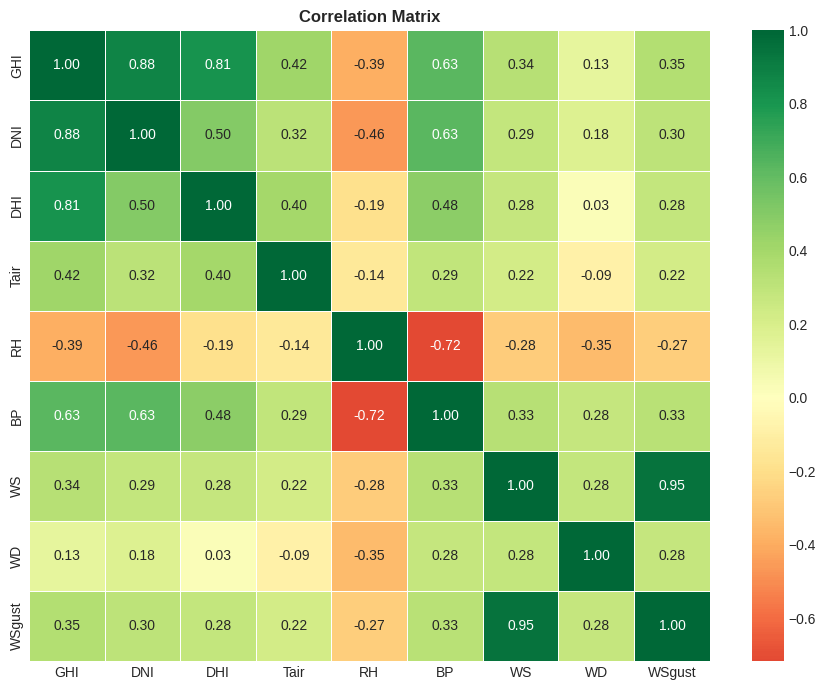

✅ Step 3 done — EDA plots saved


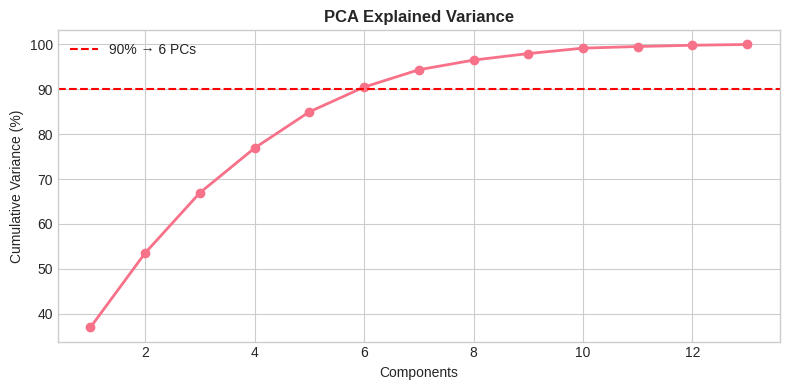


✅ Step 4 done — PCA latent shape: (44632, 6)  (90.5% variance)

Using device: cuda
  Epoch  10/60 | train 0.6910 | val 0.6802
  Epoch  20/60 | train 0.6806 | val 0.6695
  Epoch  30/60 | train 0.6775 | val 0.6605
  Epoch  40/60 | train 0.6734 | val 0.6607
  Epoch  50/60 | train 0.6709 | val 0.6590
  Epoch  60/60 | train 0.6727 | val 0.6592


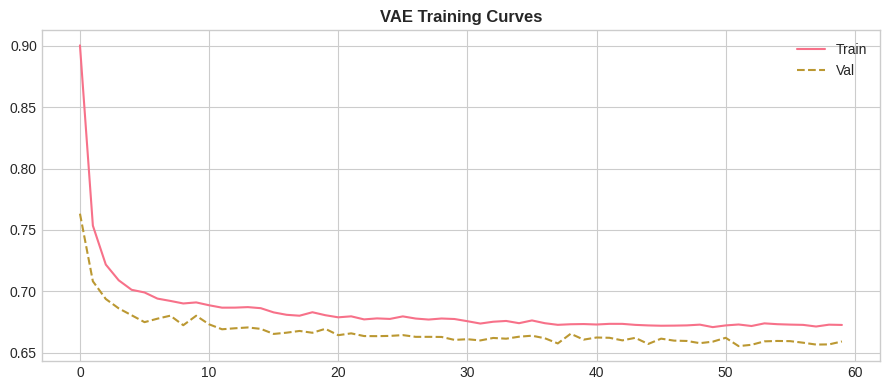


✅ Step 5 done — VAE latent shape: (44632, 8)


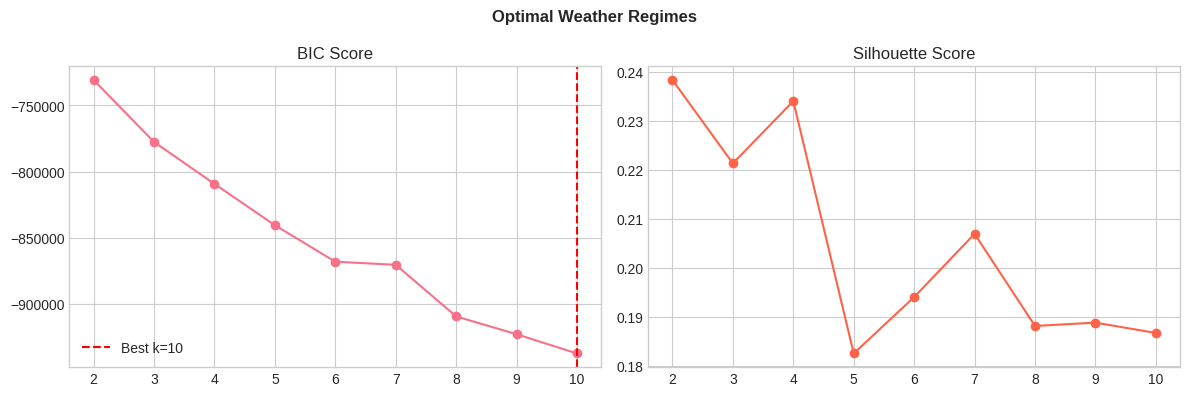


✅ Step 6 done — 10 weather regimes found
0    3218
1    3470
2    4393
3    5551
4    4499
5    2893
6    3024
7    3892
8    6411
9    7281

Computing UMAP (takes ~1 min)...


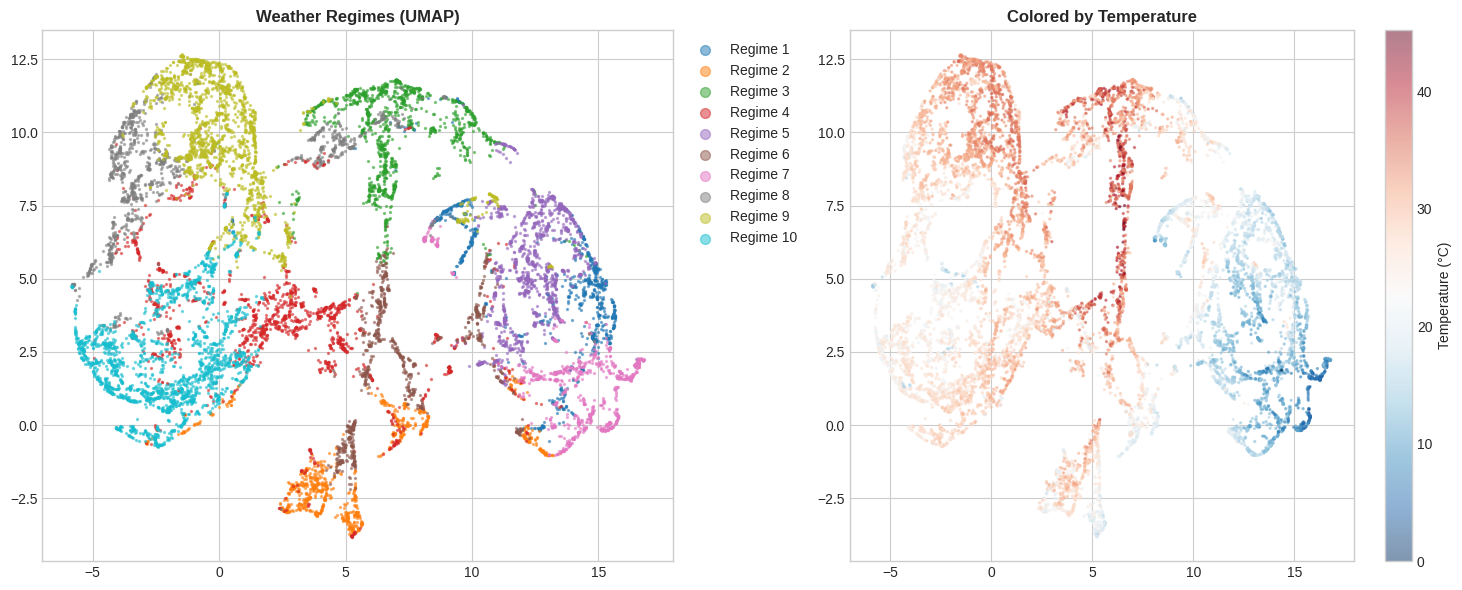

✅ Step 7 done — UMAP saved


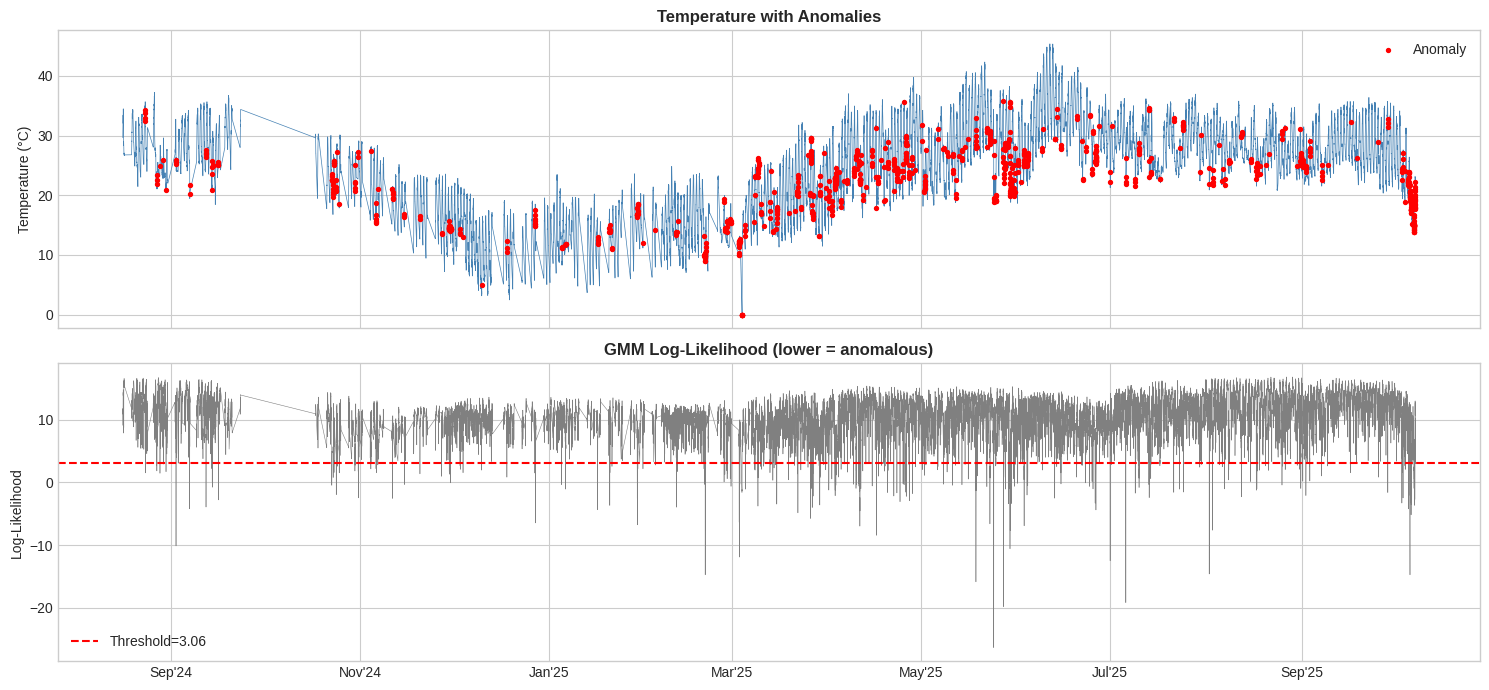


✅ Step 8 done — 893 anomalies detected (2.0%)
  LSTM Epoch 10/40 | val loss 0.02626
  LSTM Epoch 20/40 | val loss 0.02580
  LSTM Epoch 30/40 | val loss 0.02670
  LSTM Epoch 40/40 | val loss 0.02928


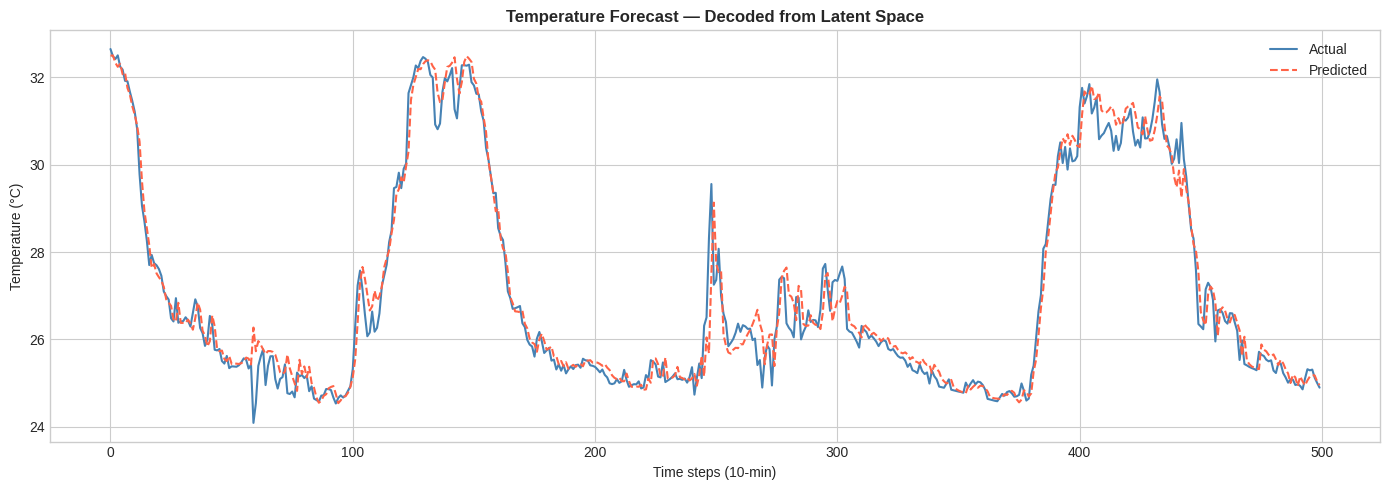


✅ Step 9 done — RMSE: 0.485°C | MAE: 0.310°C

=== KS Test: Latent Dims vs Gaussian Prior ===
Dim      KS stat      p-value      Gaussian?
---------------------------------------------
z_1      0.0568       0.0000       ⚠️
z_2      0.0169       0.0000       ⚠️
z_3      0.0779       0.0000       ⚠️
z_4      0.0424       0.0000       ⚠️
z_5      0.0270       0.0000       ⚠️
z_6      0.0404       0.0000       ⚠️
z_7      0.0151       0.0000       ⚠️
z_8      0.0446       0.0000       ⚠️


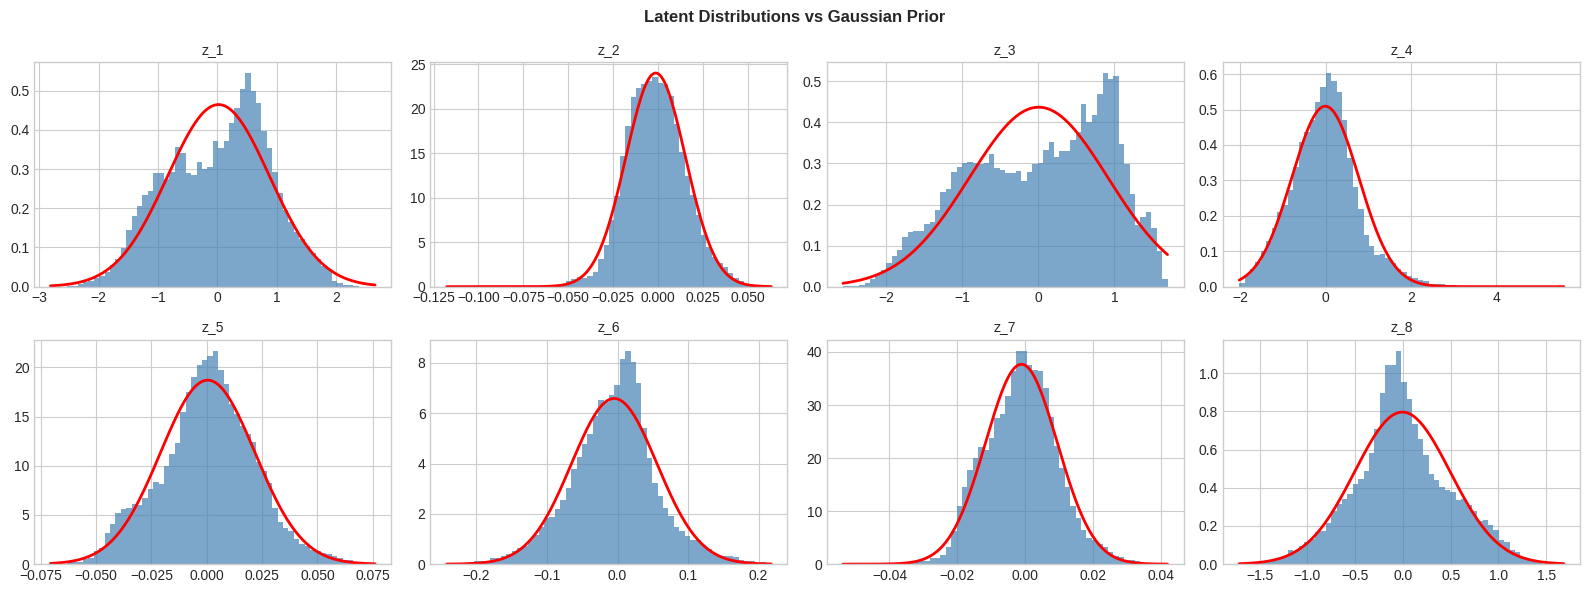

✅ Step 10 done


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


     WEATHER LATENT SPACE MODEL — COMPLETE
  Dataset      : 44,632 observations
  Period       : 2024-08-16 → 2025-10-07
  PCA dims     : 6  (90.5% variance)
  VAE dims     : 8
  GMM regimes  : 10
  Anomalies    : 893 (2.0%)
  Forecast RMSE: 0.485°C  |  MAE: 0.310°C


In [ ]:
# ============================================================
#  Weather Latent Space Statistical Model
#  Paste this entire script into a single Colab cell and run
# ============================================================

# ── STEP 0: Install & Imports ────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "umap-learn", "openpyxl", "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import umap
import warnings, joblib
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("✅ Step 0 done — libraries loaded")


# ── STEP 1: Upload & Load Data ───────────────────────────────
from google.colab import files
print("\n📁 Upload: Combined_Meteorological_Dataset_Full_Year.xlsx")
uploaded = files.upload()
FILENAME = list(uploaded.keys())[0]

# Read (3-row header: name / unit / stat-type)
df_raw = pd.read_excel(FILENAME, header=0)
COL_NAMES = ['TIMESTAMP','GHI','DNI','DHI','Tair','RH','BP','WS','WD','WSgust']
df_raw.columns = COL_NAMES
df_raw = df_raw.drop([0, 1]).reset_index(drop=True)

df_raw['TIMESTAMP'] = pd.to_datetime(df_raw['TIMESTAMP'], errors='coerce')
feature_cols = ['GHI','DNI','DHI','Tair','RH','BP','WS','WD','WSgust']
df_raw[feature_cols] = df_raw[feature_cols].apply(pd.to_numeric, errors='coerce')

print(f"Raw shape : {df_raw.shape}")
print(f"Date range: {df_raw.TIMESTAMP.min()} → {df_raw.TIMESTAMP.max()}")
print(f"Missing   :\n{df_raw.isnull().sum()}")


# ── STEP 2: Clean Data ───────────────────────────────────────
df = df_raw.dropna(subset=['TIMESTAMP']).copy()
df = df.dropna(subset=feature_cols, how='all')
df = df.sort_values('TIMESTAMP').reset_index(drop=True)
df[feature_cols] = df[feature_cols].fillna(method='ffill', limit=3)
df = df.dropna(subset=feature_cols).reset_index(drop=True)

# Temporal cyclic features
df['hour']      = df['TIMESTAMP'].dt.hour + df['TIMESTAMP'].dt.minute / 60
df['month']     = df['TIMESTAMP'].dt.month
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(f"\n✅ Step 2 done — clean shape: {df.shape}")


# ── STEP 3: EDA Plots ────────────────────────────────────────
df_daily = df.set_index('TIMESTAMP')[feature_cols].resample('D').mean()

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()
labels = ['GHI (W/m²)','DNI (W/m²)','DHI (W/m²)',
          'Temp (°C)','Humidity (%)','Pressure (mbar)',
          'Wind Speed (m/s)','Wind Dir (°)','Gust (m/s)']
for i, (col, lbl) in enumerate(zip(feature_cols, labels)):
    axes[i].plot(df_daily.index, df_daily[col], linewidth=0.8)
    axes[i].set_title(lbl, fontsize=9, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)
plt.suptitle('Daily Mean Weather Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_timeseries.png', dpi=130, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Step 3 done — EDA plots saved")


# ── STEP 4: Scale + PCA ──────────────────────────────────────
MODEL_FEATURES = feature_cols + ['hour_sin','hour_cos','month_sin','month_cos']
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[MODEL_FEATURES])

pca_full = PCA().fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
LATENT_DIM = int(np.argmax(cumvar >= 0.90)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, 'o-', linewidth=2)
ax.axhline(90, color='red', linestyle='--', label=f'90% → {LATENT_DIM} PCs')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative Variance (%)')
ax.set_title('PCA Explained Variance', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('03_pca_variance.png', dpi=130, bbox_inches='tight')
plt.show()

pca = PCA(n_components=LATENT_DIM, random_state=SEED)
Z_pca = pca.fit_transform(X_scaled)
print(f"\n✅ Step 4 done — PCA latent shape: {Z_pca.shape}  "
      f"({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")


# ── STEP 5: VAE ──────────────────────────────────────────────
class WeatherVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden=128):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2), nn.ReLU())
        self.fc_mu     = nn.Linear(hidden//2, latent_dim)
        self.fc_logvar = nn.Linear(hidden//2, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden//2), nn.ReLU(),
            nn.Linear(hidden//2, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, input_dim))

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def forward(self, x):
        h      = self.enc(x)
        mu, lv = self.fc_mu(h), self.fc_logvar(h)
        z      = self.reparameterize(mu, lv)
        return self.dec(z), mu, lv, z

def vae_loss(xr, x, mu, lv):
    recon = nn.MSELoss()(xr, x)
    kl    = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
    return recon + kl, recon, kl

VAE_LATENT = 8
BATCH      = 512
EPOCHS     = 60
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

X_tr, X_te = train_test_split(X_scaled, test_size=0.2, random_state=SEED)
tr_loader  = DataLoader(TensorDataset(torch.FloatTensor(X_tr)), batch_size=BATCH, shuffle=True)
te_loader  = DataLoader(TensorDataset(torch.FloatTensor(X_te)), batch_size=BATCH)

vae      = WeatherVAE(len(MODEL_FEATURES), VAE_LATENT).to(device)
opt_vae  = optim.Adam(vae.parameters(), lr=1e-3, weight_decay=1e-5)
sched    = optim.lr_scheduler.StepLR(opt_vae, step_size=20, gamma=0.5)

tr_losses, val_losses = [], []
for ep in range(EPOCHS):
    vae.train()
    ep_loss = 0
    for (b,) in tr_loader:
        b = b.to(device); opt_vae.zero_grad()
        xr, mu, lv, _ = vae(b)
        loss, _, _    = vae_loss(xr, b, mu, lv)
        loss.backward(); nn.utils.clip_grad_norm_(vae.parameters(), 1.0); opt_vae.step()
        ep_loss += loss.item()
    tr_losses.append(ep_loss / len(tr_loader))
    vae.eval(); vl = 0
    with torch.no_grad():
        for (b,) in te_loader:
            b = b.to(device); xr, mu, lv, _ = vae(b)
            vl += vae_loss(xr, b, mu, lv)[0].item()
    val_losses.append(vl / len(te_loader)); sched.step()
    if (ep+1) % 10 == 0:
        print(f"  Epoch {ep+1:3d}/{EPOCHS} | train {tr_losses[-1]:.4f} | val {val_losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tr_losses, label='Train'); ax.plot(val_losses, label='Val', linestyle='--')
ax.set_title('VAE Training Curves', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('04_vae_training.png', dpi=130, bbox_inches='tight'); plt.show()

# Extract latent means
vae.eval(); all_mu = []
with torch.no_grad():
    for i in range(0, len(X_scaled), BATCH):
        b = torch.FloatTensor(X_scaled[i:i+BATCH]).to(device)
        _, mu, _, _ = vae(b); all_mu.append(mu.cpu().numpy())
Z_vae = np.vstack(all_mu)
print(f"\n✅ Step 5 done — VAE latent shape: {Z_vae.shape}")


# ── STEP 6: GMM Clustering ───────────────────────────────────
bic_scores, sil_scores = [], []
for k in range(2, 11):
    g   = GaussianMixture(n_components=k, random_state=SEED, max_iter=200)
    lbl = g.fit_predict(Z_vae)
    bic_scores.append(g.bic(Z_vae))
    idx = np.random.choice(len(Z_vae), min(5000, len(Z_vae)), replace=False)
    sil_scores.append(silhouette_score(Z_vae[idx], lbl[idx]) if len(np.unique(lbl))>1 else 0)

N_CLUSTERS = list(range(2,11))[int(np.argmin(bic_scores))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2,11), bic_scores, 'o-')
axes[0].axvline(N_CLUSTERS, color='red', linestyle='--', label=f'Best k={N_CLUSTERS}')
axes[0].set_title('BIC Score'); axes[0].legend()
axes[1].plot(range(2,11), sil_scores, 'o-', color='tomato')
axes[1].set_title('Silhouette Score')
plt.suptitle('Optimal Weather Regimes', fontweight='bold')
plt.tight_layout(); plt.savefig('05_gmm_selection.png', dpi=130, bbox_inches='tight'); plt.show()

gmm    = GaussianMixture(n_components=N_CLUSTERS, random_state=SEED, max_iter=300)
labels = gmm.fit_predict(Z_vae)
df['cluster'] = labels
print(f"\n✅ Step 6 done — {N_CLUSTERS} weather regimes found")
print(pd.Series(labels).value_counts().sort_index().to_string())


# ── STEP 7: UMAP Visualization ───────────────────────────────
print("\nComputing UMAP (takes ~1 min)...")
idx_s  = np.random.choice(len(Z_vae), min(12000, len(Z_vae)), replace=False)
Z_2d   = umap.UMAP(n_components=2, random_state=SEED).fit_transform(Z_vae[idx_s])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette('tab10', N_CLUSTERS)
for c in range(N_CLUSTERS):
    m = labels[idx_s] == c
    axes[0].scatter(Z_2d[m,0], Z_2d[m,1], c=[palette[c]], s=2, alpha=0.5, label=f'Regime {c+1}')
axes[0].set_title('Weather Regimes (UMAP)', fontweight='bold')
axes[0].legend(markerscale=5, bbox_to_anchor=(1.01,1))
sc = axes[1].scatter(Z_2d[:,0], Z_2d[:,1], c=df['Tair'].values[idx_s], cmap='RdBu_r', s=2, alpha=0.5)
plt.colorbar(sc, ax=axes[1], label='Temperature (°C)')
axes[1].set_title('Colored by Temperature', fontweight='bold')
plt.tight_layout(); plt.savefig('06_umap.png', dpi=130, bbox_inches='tight'); plt.show()
print("✅ Step 7 done — UMAP saved")


# ── STEP 8: Anomaly Detection ────────────────────────────────
log_probs        = gmm.score_samples(Z_vae)
threshold        = np.percentile(log_probs, 2)
df['log_prob']   = log_probs
df['is_anomaly'] = log_probs < threshold

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
axes[0].plot(df['TIMESTAMP'], df['Tair'], linewidth=0.5, color='steelblue')
axes[0].scatter(df.loc[df['is_anomaly'],'TIMESTAMP'],
                df.loc[df['is_anomaly'],'Tair'], color='red', s=8, zorder=5, label='Anomaly')
axes[0].set_ylabel('Temperature (°C)'); axes[0].legend()
axes[0].set_title('Temperature with Anomalies', fontweight='bold')
axes[1].plot(df['TIMESTAMP'], df['log_prob'], linewidth=0.4, color='gray')
axes[1].axhline(threshold, color='red', linestyle='--', label=f'Threshold={threshold:.2f}')
axes[1].set_ylabel('Log-Likelihood'); axes[1].legend()
axes[1].set_title('GMM Log-Likelihood (lower = anomalous)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
plt.tight_layout(); plt.savefig('07_anomalies.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"\n✅ Step 8 done — {df['is_anomaly'].sum():,} anomalies detected "
      f"({df['is_anomaly'].mean()*100:.1f}%)")


# ── STEP 9: LSTM Forecasting ─────────────────────────────────
SEQ_LEN, PRED_STEPS = 36, 6

def make_sequences(Z, sl, ps):
    X_s, y_s = [], []
    for i in range(len(Z) - sl - ps + 1):
        X_s.append(Z[i:i+sl]); y_s.append(Z[i+sl:i+sl+ps])
    return np.array(X_s), np.array(y_s)

X_seq, y_seq = make_sequences(Z_vae, SEQ_LEN, PRED_STEPS)
sp = int(0.8 * len(X_seq))
Xt_tr = torch.FloatTensor(X_seq[:sp]); yt_tr = torch.FloatTensor(y_seq[:sp])
Xt_te = torch.FloatTensor(X_seq[sp:]); yt_te = torch.FloatTensor(y_seq[sp:])
seq_loader = DataLoader(TensorDataset(Xt_tr, yt_tr), batch_size=256, shuffle=True)

class LatentLSTM(nn.Module):
    def __init__(self, ld, hd=128, nl=2, ps=6):
        super().__init__()
        self.lstm = nn.LSTM(ld, hd, nl, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hd, ld * ps)
        self.ps, self.ld = ps, ld
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).view(-1, self.ps, self.ld)

lstm_model = LatentLSTM(VAE_LATENT).to(device)
opt_lstm   = optim.Adam(lstm_model.parameters(), lr=5e-4)
crit       = nn.MSELoss()

for ep in range(40):
    lstm_model.train()
    for (xb, yb) in seq_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_lstm.zero_grad()
        loss = crit(lstm_model(xb), yb)
        loss.backward(); nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0); opt_lstm.step()
    if (ep+1) % 10 == 0:
        lstm_model.eval()
        with torch.no_grad():
            vl = crit(lstm_model(Xt_te.to(device)), yt_te.to(device)).item()
        print(f"  LSTM Epoch {ep+1}/40 | val loss {vl:.5f}")

# Decode predictions back to weather space
lstm_model.eval(); vae.eval()
with torch.no_grad():
    z_pred = lstm_model(Xt_te.to(device))
    x_pred = vae.dec(z_pred[:, 0, :]).cpu().numpy()
    x_true = vae.dec(yt_te[:, 0, :].to(device)).cpu().numpy()

x_pred_orig = scaler.inverse_transform(x_pred)
x_true_orig = scaler.inverse_transform(x_true)
TEMP_IDX    = MODEL_FEATURES.index('Tair')
rmse = np.sqrt(np.mean((x_true_orig[:, TEMP_IDX] - x_pred_orig[:, TEMP_IDX])**2))
mae  = np.mean(np.abs(x_true_orig[:, TEMP_IDX] - x_pred_orig[:, TEMP_IDX]))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x_true_orig[:500, TEMP_IDX], label='Actual',    linewidth=1.5, color='steelblue')
ax.plot(x_pred_orig[:500, TEMP_IDX], label='Predicted', linewidth=1.5, color='tomato', linestyle='--')
ax.set_title('Temperature Forecast — Decoded from Latent Space', fontweight='bold')
ax.set_xlabel('Time steps (10-min)'); ax.set_ylabel('Temperature (°C)'); ax.legend()
plt.tight_layout(); plt.savefig('08_forecast.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"\n✅ Step 9 done — RMSE: {rmse:.3f}°C | MAE: {mae:.3f}°C")


# ── STEP 10: Statistical Validation ─────────────────────────
print("\n=== KS Test: Latent Dims vs Gaussian Prior ===")
print(f"{'Dim':<8} {'KS stat':<12} {'p-value':<12} {'Gaussian?'}")
print("-" * 45)
for i in range(VAE_LATENT):
    ks, p = stats.kstest(Z_vae[:, i], 'norm',
                          args=(Z_vae[:, i].mean(), Z_vae[:, i].std()))
    print(f"z_{i+1:<6} {ks:<12.4f} {p:<12.4f} {'✅' if p > 0.05 else '⚠️'}")

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i in range(VAE_LATENT):
    axes[i].hist(Z_vae[:, i], bins=60, density=True, color='steelblue', alpha=0.7)
    xr = np.linspace(Z_vae[:, i].min(), Z_vae[:, i].max(), 200)
    axes[i].plot(xr, stats.norm.pdf(xr, Z_vae[:,i].mean(), Z_vae[:,i].std()), 'r-', lw=2)
    axes[i].set_title(f'z_{i+1}', fontsize=10)
plt.suptitle('Latent Distributions vs Gaussian Prior', fontweight='bold')
plt.tight_layout(); plt.savefig('09_latent_distributions.png', dpi=130, bbox_inches='tight'); plt.show()
print("✅ Step 10 done")


# ── STEP 11: Save Everything ─────────────────────────────────
torch.save(vae.state_dict(),        'vae_model.pth')
torch.save(lstm_model.state_dict(), 'lstm_model.pth')
joblib.dump(scaler,  'scaler.pkl')
joblib.dump(pca,     'pca.pkl')
joblib.dump(gmm,     'gmm.pkl')
np.save('Z_vae_latent.npy', Z_vae)
df[['TIMESTAMP'] + feature_cols + ['cluster','log_prob','is_anomaly']].to_csv(
    'weather_results.csv', index=False)

# Download results CSV automatically
files.download('weather_results.csv')

print("\n" + "="*52)
print("     WEATHER LATENT SPACE MODEL — COMPLETE")
print("="*52)
print(f"  Dataset      : {len(df):,} observations")
print(f"  Period       : {df.TIMESTAMP.min().date()} → {df.TIMESTAMP.max().date()}")
print(f"  PCA dims     : {LATENT_DIM}  ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"  VAE dims     : {VAE_LATENT}")
print(f"  GMM regimes  : {N_CLUSTERS}")
print(f"  Anomalies    : {df['is_anomaly'].sum():,} ({df['is_anomaly'].mean()*100:.1f}%)")
print(f"  Forecast RMSE: {rmse:.3f}°C  |  MAE: {mae:.3f}°C")
print("="*52)